In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. LOAD AND SORT TIME-SERIES-LIKE DATA

df = pd.read_csv("product_monthly_panel.csv")

# We'll use 'rating' for this regression example (you can change it)
# Assumes data is already roughly time-indexed by row or has a column like 'month'
target_series = df['rating'].dropna().values.astype(np.float32)


# 2. CREATE WINDOWED INPUTS AND TARGETS

def create_windows(series, window_size=7):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i + window_size])
        y.append(series[i + window_size])
    return np.array(X), np.array(y)

window_size = 7
X_all, y_all = create_windows(target_series, window_size=window_size)



In [2]:
# 3. SPLIT INTO TRAIN/TEST SETS

test_ratio = 0.2
split_index = int(len(X_all) * (1 - test_ratio))
X_train, y_train = X_all[:split_index], y_all[:split_index]
X_test, y_test = X_all[split_index:], y_all[split_index:]

X_train_t = torch.tensor(X_train).unsqueeze(1)  # shape: (N, 1, 7)
y_train_t = torch.tensor(y_train).unsqueeze(1)  # shape: (N, 1)
X_test_t = torch.tensor(X_test).unsqueeze(1)
y_test_t = torch.tensor(y_test).unsqueeze(1)



In [3]:
# 4. DATA LOADERS
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)



In [4]:
# 5. DEFINE CNN MODEL

class CNN1DRegressor(nn.Module):
    def __init__(self):
        super(CNN1DRegressor, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3),
            nn.ReLU()
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(32 * 3, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        return self.fc_layers(x)

model = CNN1DRegressor()


In [5]:
# 6. LOSS AND OPTIMIZER

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)



In [6]:
# 7. TRAINING LOOP
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        preds = model(batch_X)
        loss = criterion(preds, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}, Avg Loss: {total_loss / len(train_loader):.4f}")


Epoch 5/20, Avg Loss: 0.8232
Epoch 10/20, Avg Loss: 0.8199
Epoch 15/20, Avg Loss: 0.8172
Epoch 20/20, Avg Loss: 0.8155


In [7]:
# 8. EVALUATE MODEL

model.eval()
with torch.no_grad():
    test_preds, test_targets = [], []
    for batch_X, batch_y in test_loader:
        test_preds.append(model(batch_X).numpy())
        test_targets.append(batch_y.numpy())

test_preds = np.concatenate(test_preds).flatten()
test_targets = np.concatenate(test_targets).flatten()

mse = np.mean((test_preds - test_targets) ** 2)
rmse = np.sqrt(mse)

print(f"\nTest MSE:  {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")



Test MSE:  0.9000
Test RMSE: 0.9487


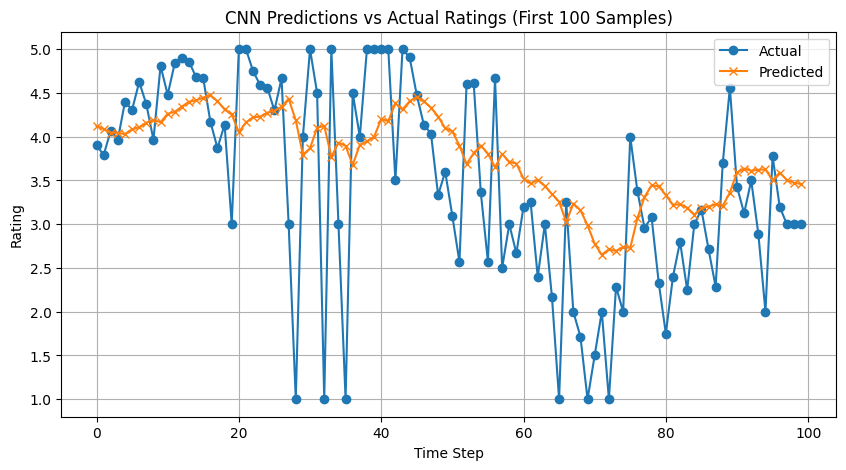

In [8]:
# 9. PLOT RESULTS

plt.figure(figsize=(10, 5))
plt.plot(test_targets[:100], label='Actual', marker='o')
plt.plot(test_preds[:100], label='Predicted', marker='x')
plt.title("CNN Predictions vs Actual Ratings (First 100 Samples)")
plt.xlabel("Time Step")
plt.ylabel("Rating")
plt.legend()
plt.grid(True)
plt.show()
